In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/online_retail_II_dataset.csv", parse_dates=["InvoiceDate"])
print(df.shape)
df.head()

(18810, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,491067,85006,PACK OF 72 RETROSPOT CAKE CASES,4,2009-12-07 15:31:00,0.55,13002.0,United Kingdom
1,491067,85012,HOT WATER BOTTLE KEEP CALM,1,2009-12-07 15:31:00,4.25,13002.0,United Kingdom
2,491067,85005,ASSORTED COLOUR BIRD ORNAMENT,6,2009-12-07 15:31:00,1.69,13002.0,United Kingdom
3,491067,85013,WOODEN FRAME ANTIQUE WHITE,6,2009-12-07 15:31:00,2.55,13002.0,United Kingdom
4,491067,85018,RED TOADSTOOL LED NIGHT LIGHT,1,2009-12-07 15:31:00,1.25,13002.0,United Kingdom


In [3]:
df.info()
print(df.isnull().sum())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18810 entries, 0 to 18809
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Invoice      18810 non-null  object        
 1   StockCode    18810 non-null  int64         
 2   Description  18810 non-null  object        
 3   Quantity     18810 non-null  int64         
 4   InvoiceDate  18810 non-null  datetime64[ns]
 5   Price        18810 non-null  float64       
 6   Customer ID  18100 non-null  float64       
 7   Country      18810 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 1.1+ MB
Invoice          0
StockCode        0
Description      0
Quantity         0
InvoiceDate      0
Price            0
Customer ID    710
Country          0
dtype: int64


,StockCode,Quantity,InvoiceDate,Price,Customer ID
count,18810.000000,18810.000000,18810,18810.000000,18100.000000
mean,85011.467996,5.376077,2011-02-08 10:53:08.102073344,3.077460,13111.500000
min,85000.000000,-24.000000,2009-12-07 15:31:00,0.550000,12346.000000
25%,85005.000000,2.000000,2010-08-30 08:07:00,1.450000,12730.000000
50%,85012.000000,4.000000,2011-02-06 17:55:00,2.080000,13125.000000
75%,85018.000000,6.000000,2011-08-03 09:20:00,4.250000,13497.000000
max,85023.000000,24.000000,2011-12-09 17:59:00,10.950000,13845.000000
std,6.957621,5.546068,NaN,2.353597,430.264086


In [4]:
df = df.dropna(subset=["Customer ID"])                    # removing guest orders
df = df[~df["Invoice"].astype(str).str.startswith("C")]   # removing cancellations
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]         # removing false rows
df["Customer ID"] = df["Customer ID"].astype(int)
df["Revenue"] = df["Quantity"] * df["Price"]
print("Clean shape:", df.shape)

Clean shape: (17745, 9)


In [5]:
orders = (df.groupby(["Customer ID", "Invoice"])
            .agg(OrderDate=("InvoiceDate", "min"),
                 OrderValue=("Revenue", "sum"))
            .reset_index()
            .sort_values(["Customer ID", "OrderDate"]))

orders["OrderNo"] = orders.groupby("Customer ID").cumcount() + 1
orders.head()

,Customer ID,Invoice,OrderDate,OrderValue,OrderNo
0,12346,489435,2011-06-17 16:52:00,101.76,1
1,12347,489436,2011-12-09 11:05:00,65.20,1
2,12348,489437,2011-10-08 14:08:00,166.69,1
3,12349,489438,2011-08-09 10:14:00,5.00,1
4,12349,489439,2011-10-11 08:43:00,32.36,2


In [6]:
cust = (orders.groupby("Customer ID")
              .agg(Orders=("Invoice", "nunique"),
                   TotalSpend=("OrderValue", "sum"),
                   AOV=("OrderValue", "mean"))
              .reset_index())

cust["IsRepeat"] = cust["Orders"] >= 2   # 2+ orders = repeat customer
cust.head()

,Customer ID,Orders,TotalSpend,AOV,IsRepeat
0,12346,1,101.76,101.76,False
1,12347,1,65.20,65.20,False
2,12348,1,166.69,166.69,False
3,12349,2,37.36,18.68,True
4,12350,1,13.65,13.65,False


In [7]:
repeat_rate = cust["IsRepeat"].mean() * 100
print("Total customers :", len(cust))
print("Repeat customers:", cust["IsRepeat"].sum())
print(f"Repeat rate     : {repeat_rate:.2f}%")

Total customers : 1500
Repeat customers: 781
Repeat rate     : 52.07%


In [8]:
def segment(n):
    if n == 1: return "One-time"
    if n <= 3: return "Occasional (2-3)"
    if n <= 6: return "Regular (4-6)"
    return "Loyal (7+)"

cust["Segment"] = cust["Orders"].apply(segment)
order_cat = ["One-time", "Occasional (2-3)", "Regular (4-6)", "Loyal (7+)"]

seg = (cust.groupby("Segment")
           .agg(Customers=("Customer ID", "count"),
                AvgOrders=("Orders", "mean"),
                AvgAOV=("AOV", "mean"),
                TotalRevenue=("TotalSpend", "sum"))
           .reindex(order_cat))

seg["%Customers"] = seg["Customers"] / seg["Customers"].sum() * 100
seg["%Revenue"] = seg["TotalRevenue"] / seg["TotalRevenue"].sum() * 100
seg = seg.round(2)
seg

,Customers,AvgOrders,AvgAOV,TotalRevenue,%Customers,%Revenue
Segment,,,,,,
One-time,719,1.00,77.27,55556.20,47.93,18.18
Occasional (2-3),439,2.39,77.06,80878.66,29.27,26.47
Regular (4-6),227,4.75,77.62,83458.22,15.13,27.31
Loyal (7+),115,9.44,78.63,85699.29,7.67,28.04


In [9]:
orders["Type"] = orders["OrderNo"].apply(
    lambda x: "First-time order" if x == 1 else "Repeat order")

aov = orders.groupby("Type")["OrderValue"].agg(["count", "mean", "median"]).round(2)
aov

,count,mean,median
Type,,,
First-time order,1500,77.98,64.22
Repeat order,2431,77.59,64.35


In [10]:
first = orders[orders["OrderNo"] == 1].set_index("Customer ID")["OrderDate"]
second = orders[orders["OrderNo"] == 2].set_index("Customer ID")["OrderDate"]
gap = (second - first).dropna().dt.days
print(f"Average days between 1st and 2nd order: {gap.mean():.1f}")

Average days between 1st and 2nd order: 45.3


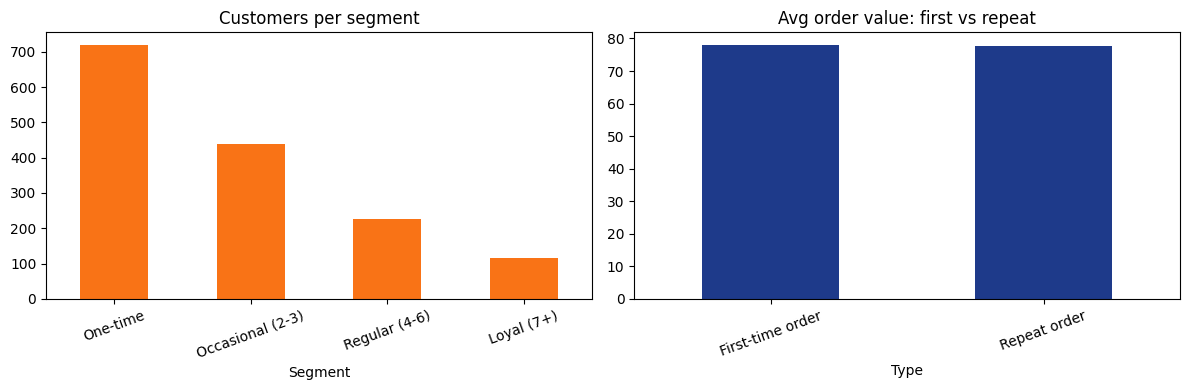

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
seg["Customers"].plot.bar(ax=ax[0], color="#f97316")
ax[0].set_title("Customers per segment")
aov["mean"].plot.bar(ax=ax[1], color="#1e3a8a")
ax[1].set_title("Avg order value: first vs repeat")
for a in ax:
    a.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("task28_charts.png", dpi=150)
plt.show()